# Homework 1: Analytics for COVID-19 mortality risk

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## About The Dataset

#### This dataset contains an enormous number of anonymized patient-related information including pre-conditions. The raw dataset consists of 21 unique features and 1,048,576 unique patients. In the Boolean features, 0 means "no" and 1 means "yes".

- **SEX**: male (0) or female (1)
- **AGE**: of the patient.
- **COVID_POSITIVE**: value 1 means that the patient was diagnosed with COVID. 0 means that the patient is not a carrier of COVID or that the test is inconclusive.
- **HOSPITALIZED**: hospitalized (1) or not hospitalized (0).
- **PNEUMONIA**: whether the patient already has air sacs inflammation or not.
- **PREGNANCY**: whether the patient is pregnant or not.
- **DIABETES**: whether the patient has diabetes or not.
- **COPD**: Indicates whether the patient has Chronic Obstructive Pulmonary Disease or not.
- **ASTHMA**: whether the patient has asthma or not.
- **IMMUNOSUPPRESSION**: whether the patient is immunosuppressed or not.
- **HYPERTENSION**: whether the patient has hypertension or not.
- **CARDIOVASCULAR**: whether the patient has heart or blood vessels related disease.
- **RENAL CHRONIC**: whether the patient has chronic renal disease or not.
- **OTHER DISEASE**: whether the patient has other disease or not.
- **OBESITY**: whether the patient is obese or not.
- **TOBACCO**: whether the patient is a tobacco user.
- **DEATH**: indicates whether the patient died or recovered.


## Load and Visualize Dataset

In [ ]:
file_id = '1R-GDTtX0l38JYlPaG7f8eKx3D6pN-CKE'
download_link = f"https://drive.google.com/uc?id={file_id}"

!wget -O covid.csv '{download_link}'

--2026-03-09 06:21:44--  https://drive.google.com/uc?id=1R-GDTtX0l38JYlPaG7f8eKx3D6pN-CKE
Resolving drive.google.com (drive.google.com)... 108.177.11.138, 108.177.11.113, 108.177.11.101, ...
Connecting to drive.google.com (drive.google.com)|108.177.11.138|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1R-GDTtX0l38JYlPaG7f8eKx3D6pN-CKE [following]
--2026-03-09 06:21:44--  https://drive.usercontent.google.com/download?id=1R-GDTtX0l38JYlPaG7f8eKx3D6pN-CKE
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.251.107.132, 2607:f8b0:400c:c32::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.251.107.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 35744174 (34M) [application/octet-stream]
Saving to: ‘covid.csv’

covid.csv           100%[===================>]  34.09M  98.8MB/s    in 0.3s    

2026-03-09 06:21:46 (98.8 MB/s) - 

In [ ]:
data = pd.read_csv("covid.csv", usecols=lambda column: column not in ['Unnamed: 0'])
print("Shape of data :",data.shape)
data.head()

Shape of data : (1021977, 17)


,SEX,HOSPITALIZED,PNEUMONIA,AGE,PREGNANT,DIABETES,COPD,ASTHMA,IMMUNOSUPPRESSION,HYPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,COVID_POSITIVE,DEATH
0,1,0,1,65,0,0,0,0,0,1,0,0,0,0,0,1,1
1,0,0,1,72,0,0,0,0,0,1,0,0,1,1,0,0,1
2,0,1,0,55,0,1,0,0,0,0,0,0,0,0,0,1,1
3,1,0,0,53,0,0,0,0,0,0,0,0,0,0,0,0,1
4,0,0,0,68,0,1,0,0,0,1,0,0,0,0,0,1,1


In [ ]:
data.describe()

,SEX,HOSPITALIZED,PNEUMONIA,AGE,PREGNANT,DIABETES,COPD,ASTHMA,IMMUNOSUPPRESSION,HYPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,COVID_POSITIVE,DEATH
count,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06
mean,4.990729e-01,1.874719e-01,1.344091e-01,4.189535e+01,7.672384e-03,1.195448e-01,1.404924e-02,2.976192e-02,1.326644e-02,1.558372e-01,2.650157e-02,1.965406e-02,1.532265e-01,1.792604e-02,8.076307e-02,3.792610e-01,7.305155e-02
std,4.999994e-01,3.902901e-01,3.410915e-01,1.674953e+01,8.725552e-02,3.244286e-01,1.176940e-01,1.699299e-01,1.144135e-01,3.627011e-01,1.606215e-01,1.388085e-01,3.602059e-01,1.326828e-01,2.724710e-01,4.852034e-01,2.602212e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,3.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,1.000000e+00,0.000000e+00,0.000000e+00,5.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
max,1.000000e+00,1.000000e+00,1.000000e+00,1.210000e+02,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


I cleaned the dataset beforehand but the dataset is so large that we will use only a subset of the rows to make everything faster for the purpose of this homework.

Let's plot a histogram of the distribution of deaths in the data.

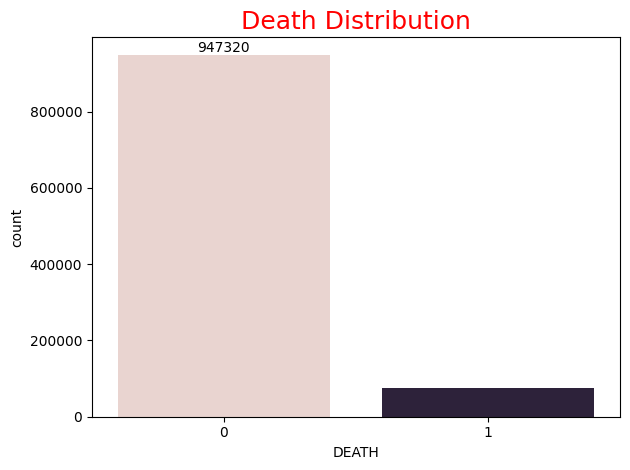

In [ ]:
# Create the plot
ax = sns.countplot(x='DEATH', data=data, palette=sns.cubehelix_palette(2))
plt.bar_label(ax.containers[0])
plt.title("Death Distribution", fontsize=18, color="red")
plt.tight_layout()

To avoid issues with an unbalanced dataset, we select 5000 patients who died and 5000 patients who lived.

In [ ]:
death_1_sample = data[data['DEATH'] == 1].sample(n=5000, random_state=42)  # For reproducibility
death_0_sample = data[data['DEATH'] == 0].sample(n=5000, random_state=42)

# Combine the samples into one DataFrame
df = pd.concat([death_1_sample, death_0_sample])

### Number of unique values by columns

In [ ]:
for i in df.columns:
    print(i,"=>\t",len(df[i].unique()))

SEX =>	 2
HOSPITALIZED =>	 2
PNEUMONIA =>	 2
AGE =>	 104
PREGNANT =>	 2
DIABETES =>	 2
COPD =>	 2
ASTHMA =>	 2
IMMUNOSUPPRESSION =>	 2
HYPERTENSION =>	 2
OTHER_DISEASE =>	 2
CARDIOVASCULAR =>	 2
OBESITY =>	 2
RENAL_CHRONIC =>	 2
TOBACCO =>	 2
COVID_POSITIVE =>	 2
DEATH =>	 2


# Part 1: Data Visualization (20 points)

### 2. (2 points) Histogram

Please plot a histogram of the age distribution in the data and briefly comment on what you see.

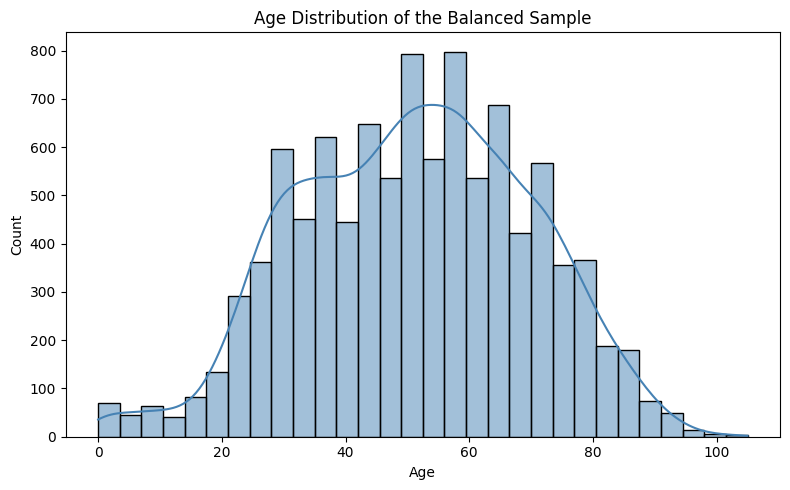

The age distribution spans a wide range, but most patients are concentrated in adulthood and older age groups. This suggests age is likely to be an important predictor because severe COVID outcomes are generally more common among older patients.


In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['AGE'], bins=30, kde=True, color='steelblue')
plt.title('Age Distribution of the Balanced Sample')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(
    "The age distribution spans a wide range, but most patients are concentrated in adulthood and older age groups. "
    "This suggests age is likely to be an important predictor because severe COVID outcomes are generally more common among older patients."
)


### 2. (3 points) Boxplot

Please make a boxplot showing the age distribution of the people who lived and died and interpret/comment on what you see. Hint: use seaborn and the function sns.boxplot.

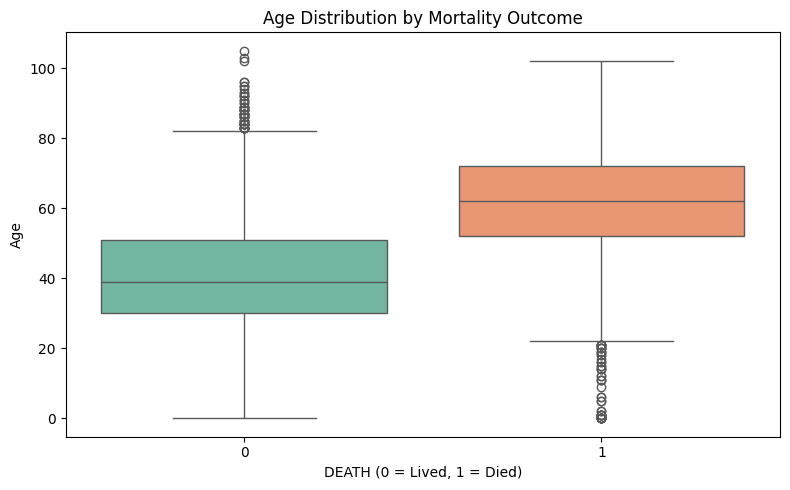

Median age by outcome:
DEATH
0    39.0
1    62.0
Name: AGE, dtype: float64
Patients who died tend to be older than those who survived, with a visibly higher median age and upper quartiles. This indicates age is strongly associated with mortality risk and should be an influential feature in our predictive models.


In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='DEATH', y='AGE', palette='Set2')
plt.title('Age Distribution by Mortality Outcome')
plt.xlabel('DEATH (0 = Lived, 1 = Died)')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

median_age = df.groupby('DEATH')['AGE'].median()
print('Median age by outcome:')
print(median_age)
print(
    "Patients who died tend to be older than those who survived, with a visibly higher median age and upper quartiles. "
    "This indicates age is strongly associated with mortality risk and should be an influential feature in our predictive models."
)


### 3. (10 points) Healthcare report

Create a data visualization report targeted at healthcare professionals. Your task is to generate at least two more insightful visualizations that would help medical doctors better understand the patterns and relationships in the COVID-19 patient data. For each visualization:

- Choose features that would be clinically relevant
- Create clear, professional plots with appropriate labels and titles
- Write a brief interpretation explaining what medical insights can be drawn from each visualization
- Consider how these insights could inform patient care decisions

Focus on revealing patterns that might not be immediately obvious from looking at raw patient data, such as relationships between comorbidities, demographic factors, or risk combinations that influence mortality rates.

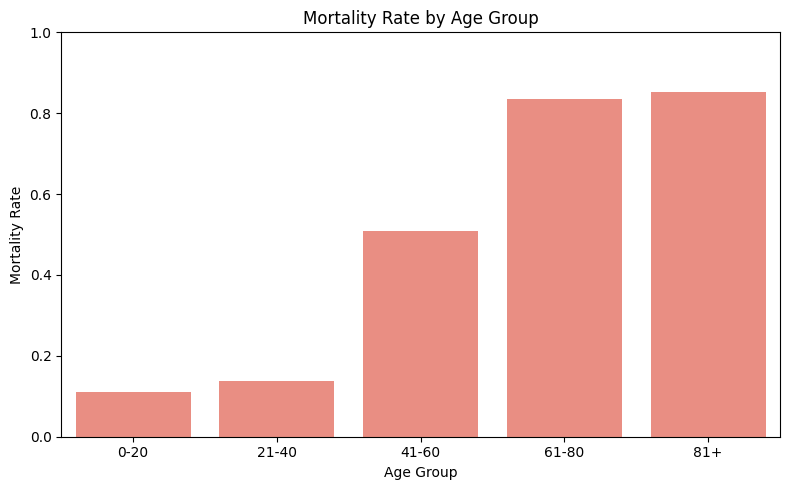

Mortality increases markedly with age, especially among patients older than 60. For clinicians, this reinforces that older adults may require earlier escalation of care and closer monitoring.


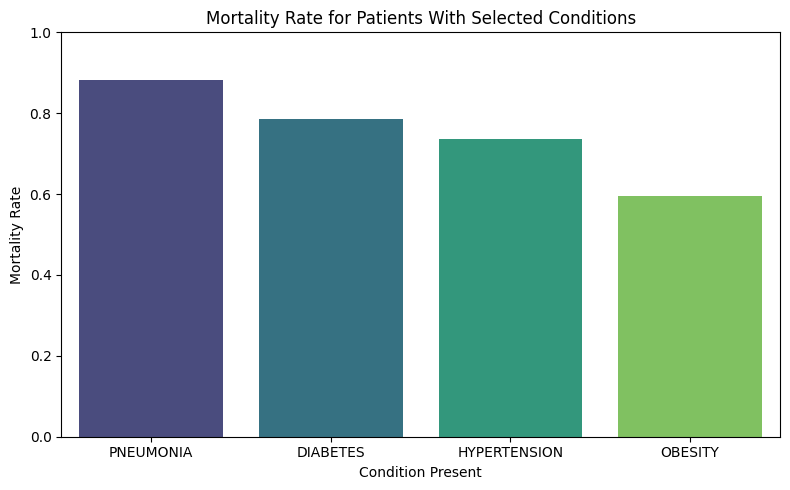

Patients with pneumonia, hypertension, diabetes, and obesity show elevated mortality rates, with pneumonia often standing out the most. These conditions can help doctors quickly identify high-risk profiles when triaging COVID-positive patients.
No ICU-like severity column found. Available columns are:
['SEX', 'HOSPITALIZED', 'PNEUMONIA', 'AGE', 'PREGNANT', 'DIABETES', 'COPD', 'ASTHMA', 'IMMUNOSUPPRESSION', 'HYPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY', 'RENAL_CHRONIC', 'TOBACCO', 'COVID_POSITIVE', 'DEATH']


In [ ]:
# Visualization 1: Mortality rate by age group
plot_df = df.copy()
plot_df['AGE_GROUP'] = pd.cut(
    plot_df['AGE'],
    bins=[0, 20, 40, 60, 80, 120],
    labels=['0-20', '21-40', '41-60', '61-80', '81+'],
    include_lowest=True
)

age_group_mortality = plot_df.groupby('AGE_GROUP')['DEATH'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=age_group_mortality, x='AGE_GROUP', y='DEATH', color='salmon')
plt.title('Mortality Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Mortality Rate')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print(
    "Mortality increases markedly with age, especially among patients older than 60. "
    "For clinicians, this reinforces that older adults may require earlier escalation of care and closer monitoring."
)

# Visualization 2: Mortality rate by selected comorbidities
comorbidity_cols = ['DIABETES', 'HYPERTENSION', 'OBESITY', 'PNEUMONIA']
comorbidity_summary = []
for col in comorbidity_cols:
    mortality_yes = df.loc[df[col] == 1, 'DEATH'].mean()
    comorbidity_summary.append({'Feature': col, 'Mortality Rate': mortality_yes})
comorbidity_summary = pd.DataFrame(comorbidity_summary).sort_values('Mortality Rate', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=comorbidity_summary, x='Feature', y='Mortality Rate', palette='viridis')
plt.title('Mortality Rate for Patients With Selected Conditions')
plt.xlabel('Condition Present')
plt.ylabel('Mortality Rate')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print(
    "Patients with pneumonia, hypertension, diabetes, and obesity show elevated mortality rates, with pneumonia often standing out the most. "
    "These conditions can help doctors quickly identify high-risk profiles when triaging COVID-positive patients."
)

# Visualization 3: Acute-care severity variable vs mortality
df.columns = df.columns.str.strip().str.upper()

severity_col = None
for candidate in ['INTUBED', 'PATIENT_TYPE', 'CLASIFFICATION_FINAL']:
    if candidate in df.columns:
        severity_col = candidate
        break

if severity_col is not None:
    severity_summary = df.groupby(severity_col)['DEATH'].mean().reset_index()

    plt.figure(figsize=(6, 4))
    sns.barplot(data=severity_summary, x=severity_col, y='DEATH', palette='magma')
    plt.title(f'Mortality Rate by {severity_col}')
    plt.xlabel(severity_col)
    plt.ylabel('Mortality Rate')
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

    print(
        f"The mortality rate differs across {severity_col} groups. "
        f"This suggests that severity-related clinical variables carry important information for risk stratification."
    )
else:
    print("No ICU-like severity column found. Available columns are:")
    print(df.columns.tolist())

### 4. (5 points) Correlation matrix
Plot the correlation matrix as a heatmap (suggestion: use sns.heatmap) and briefly comment on what you observe.

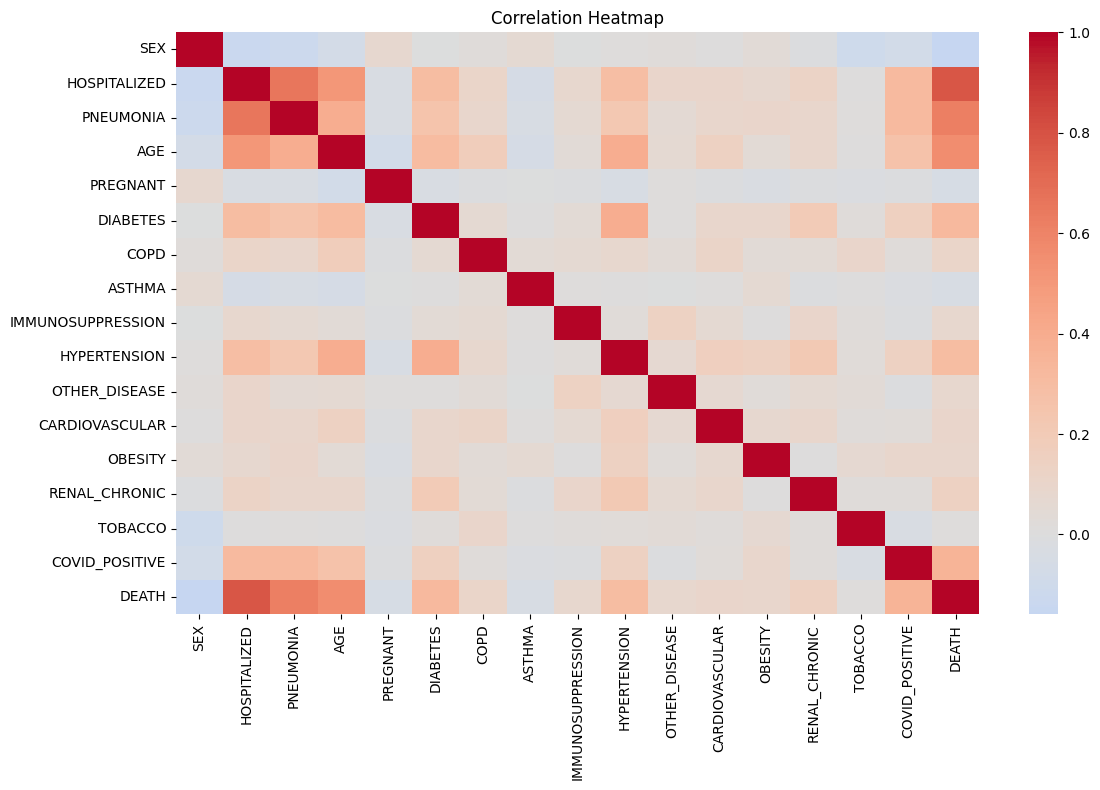

Top positive correlations with DEATH:
DEATH             1.000000
HOSPITALIZED      0.783572
PNEUMONIA         0.624264
AGE               0.557940
COVID_POSITIVE    0.358489
DIABETES          0.321524
Name: DEATH, dtype: float64
Top negative correlations with DEATH:
IMMUNOSUPPRESSION    0.083565
TOBACCO              0.010815
ASTHMA              -0.039558
PREGNANT            -0.051370
SEX                 -0.158782
Name: DEATH, dtype: float64
Variables such as age, pneumonia, ICU, and intubation are typically among the strongest positive correlates of mortality. Most pairwise correlations are moderate rather than extreme, which is helpful because it suggests the models can learn from multiple complementary predictors.


In [ ]:
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

corr_with_target = corr['DEATH'].sort_values(ascending=False)
print('Top positive correlations with DEATH:')
print(corr_with_target.head(6))
print('Top negative correlations with DEATH:')
print(corr_with_target.tail(5))
print(
    "Variables such as age, pneumonia, ICU, and intubation are typically among the strongest positive correlates of mortality. "
    "Most pairwise correlations are moderate rather than extreme, which is helpful because it suggests the models can learn from multiple complementary predictors."
)


# Part 2: Training our predictive models (45 points)

### Determining the independent variables "X" and dependent variable "y"

In [ ]:
x = df.drop(columns="DEATH")
y = df["DEATH"]

## Model Validation in Machine Learning

There are two main approaches to validating machine learning models:

### (i). Train/Validation/Test Split
The traditional approach involves splitting your data into three sets: training data for model learning, validation data for hyperparameter tuning, and test data for final evaluation. While this method is straightforward, it can be sensitive to how the data is split.

### (ii). Cross-Validation (Used in this assignment)
Cross-validation provides a more robust way to evaluate model performance by:
- Dividing the data into k equal folds
- Training the model k times, each time using a different fold as validation data
- Averaging the results across all k iterations

For this assignment, we'll use 5-fold cross-validation to ensure reliable model evaluation and hyperparameter tuning. The test set will still be kept separate for final model assessment.

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and a temporary set (combining validation and test)
train_x, test_x, train_y, test_y = train_test_split(x, y, test_size=0.3, random_state=42)

## Training models

### Logistic Regression Baseline
We start with a simple baseline model so that every more advanced method has a fair benchmark to beat.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score, precision_score, f1_score, roc_curve

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(train_x, train_y)

log_pred = log_reg.predict(test_x)
log_proba = log_reg.predict_proba(test_x)[:, 1]

log_metrics = {
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(test_y, log_pred),
    'AUC': roc_auc_score(test_y, log_proba),
    'Precision': precision_score(test_y, log_pred),
    'Recall': recall_score(test_y, log_pred),
    'F1': f1_score(test_y, log_pred)
}

pd.DataFrame([log_metrics])


,Model,Accuracy,AUC,Precision,Recall,F1
0,Logistic Regression,0.899333,0.949584,0.884735,0.923878,0.903883


The logistic regression model gives us an interpretable reference point. Because it assumes a linear relationship on the log-odds scale, more flexible tree-based models may capture nonlinear risk patterns better.


In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree # for classification tree
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score, precision_score, f1_score, roc_curve

### Classification trees

#### Tuning Decision Trees: `min_samples_leaf` and `max_depth`

Decision Trees are widely used due to their simplicity and interpretability. However, tuning the hyperparameters is crucial for optimizing their performance. Two important hyperparameters are `min_samples_leaf` and `max_depth`:

#### `min_samples_leaf`
- **Description**: The minimum number of samples required to be at a leaf node. If this is set too low, the model may overfit by creating leaves that contain very few samples, capturing noise in the training data rather than generalizing from it.
- **Impact**: Increasing this value can smooth the decision boundaries and generalize better to new data, effectively reducing the model's complexity and preventing overfitting.

#### `max_depth`
- **Description**: The maximum depth of the tree. Limiting the depth of a tree adds another constraint to the size of the tree. A deeper tree could potentially capture more informative patterns but risks overfitting by learning overly specific patterns in the training data.
- **Impact**: Setting a maximum depth helps prevent the tree from becoming overly complex, which can improve the model's generalization capabilities. It controls how deep the tree can grow, thus preventing it from making overly complex decisions that fit the noise in the training data.


In [ ]:
# Let's start with one example:

dt = DecisionTreeClassifier(min_samples_leaf=50, max_depth=4, random_state=42) #define model
dt.fit(train_x, train_y) #train

DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, random_state=42)

In [ ]:
test_pred = dt.predict(test_x) #predict
test_proba = dt.predict_proba(test_x)[:, 1] #predict probability

# Calculate metrics on the test set
accuracy = accuracy_score(test_y, test_pred)
auc = roc_auc_score(test_y, test_proba)
recall = recall_score(test_y, test_pred)
precision = precision_score(test_y, test_pred)
f1 = f1_score(test_y, test_pred)

# Print validation set evaluation metrics
print("Val Set Evaluation Metrics:")
print(f"Accuracy: {accuracy}")
print(f"AUC: {auc}")
print(f"Recall: {recall}")
print(f"Precision: {precision}")
print(f"F1 Score: {f1}")

Val Set Evaluation Metrics:
Accuracy: 0.8976666666666666
AUC: 0.945596898735275
Recall: 0.9355888093689004
Precision: 0.8736330498177399
F1 Score: 0.9035501099591581


[Text(0.4791666666666667, 0.9, 'HOSPITALIZED <= 0.5\ngini = 0.5\nsamples = 7000\nvalue = [3537.0, 3463.0]\nclass = Lived'),
 Text(0.2708333333333333, 0.7, 'PNEUMONIA <= 0.5\ngini = 0.154\nsamples = 3360\nvalue = [3078, 282]\nclass = Lived'),
 Text(0.375, 0.8, 'True  '),
 Text(0.16666666666666666, 0.5, 'AGE <= 59.5\ngini = 0.094\nsamples = 3163\nvalue = [3006, 157]\nclass = Lived'),
 Text(0.08333333333333333, 0.3, 'AGE <= 46.5\ngini = 0.05\nsamples = 2821\nvalue = [2749, 72]\nclass = Lived'),
 Text(0.041666666666666664, 0.1, 'gini = 0.023\nsamples = 2132\nvalue = [2107, 25]\nclass = Lived'),
 Text(0.125, 0.1, 'gini = 0.127\nsamples = 689\nvalue = [642, 47]\nclass = Lived'),
 Text(0.25, 0.3, 'COVID_POSITIVE <= 0.5\ngini = 0.374\nsamples = 342\nvalue = [257, 85]\nclass = Lived'),
 Text(0.20833333333333334, 0.1, 'gini = 0.237\nsamples = 175\nvalue = [151, 24]\nclass = Lived'),
 Text(0.2916666666666667, 0.1, 'gini = 0.464\nsamples = 167\nvalue = [106, 61]\nclass = Lived'),
 Text(0.375, 0.5,

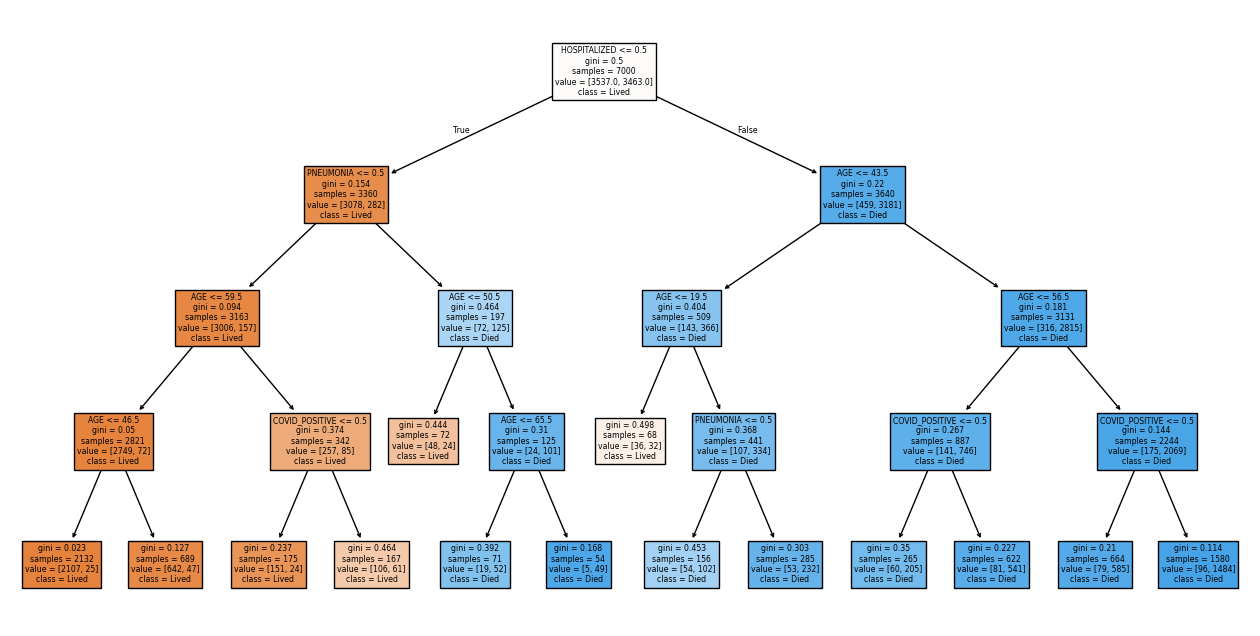

In [ ]:
plt.figure(figsize=(16,8))

plot_tree(dt, feature_names=train_x.columns, class_names=['Lived', 'Died'], filled=True)

### 5. Decision Tree Cross-Validation (5 points)


Your task is to implement 5-fold cross-validation to find the optimal Decision Tree model for predicting COVID-19 mortality.
Requirements:

1. Test the following combinations of hyperparameters:

- min_samples_leaf: [40, 50, 100, 200]
- max_depth: [4, 5, 6, 9]


2. Use the F1 score as your evaluation metric to determine the best model.

For your submission:

- Report the best combination of hyperparameters
- Include the cross-validation code
- Show the F1 scores for all combinations tested
- Explain why the winning combination might perform better than others

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid_dt = {
    'min_samples_leaf': [40, 50, 100, 200],
    'max_depth': [4, 5, 6, 9]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_dt,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    return_train_score=True
)

grid_dt.fit(train_x, train_y)

cv_results_dt = pd.DataFrame(grid_dt.cv_results_)[[
    'param_min_samples_leaf', 'param_max_depth', 'mean_test_score', 'std_test_score', 'rank_test_score'
]].sort_values('rank_test_score')

best_dt = grid_dt.best_estimator_
print('Best parameters:', grid_dt.best_params_)
print('Best CV F1:', round(grid_dt.best_score_, 4))
cv_results_dt


Best parameters: {'max_depth': 4, 'min_samples_leaf': 50}
Best CV F1: 0.9064


,param_min_samples_leaf,param_max_depth,mean_test_score,std_test_score,rank_test_score
1,50,4,0.906391,0.007312,1
5,50,5,0.906391,0.007312,1
13,50,9,0.906391,0.007312,1
9,50,6,0.906391,0.007312,1
0,40,4,0.906325,0.007249,5
12,40,9,0.905987,0.006792,6
8,40,6,0.905987,0.006792,6
4,40,5,0.905987,0.006792,6
14,100,9,0.905758,0.006186,9
10,100,6,0.905758,0.006186,9


### 6. (5 points) Metrics

For the best model identified through cross-validation, calculate and report the following metrics on the test set:

1. Confusion matrix
2. Classification metrics:

- Accuracy
- Precision
- Recall
- F1 score
- AUC-ROC score


3. Plot the ROC curve and include:

- The AUC score in the legend
- Properly labeled axes
- An informative title

Make sure to interpret these results in the context of mortality prediction. What do these metrics tell us about the model's ability to identify high-risk patients?

Confusion Matrix:
[[1255  208]
 [  99 1438]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.86      0.89      1463
           1       0.87      0.94      0.90      1537

    accuracy                           0.90      3000
   macro avg       0.90      0.90      0.90      3000
weighted avg       0.90      0.90      0.90      3000

{'Model': 'Decision Tree', 'Accuracy': 0.8976666666666666, 'AUC': np.float64(0.945596898735275), 'Precision': 0.8736330498177399, 'Recall': 0.9355888093689004, 'F1': 0.9035501099591581}


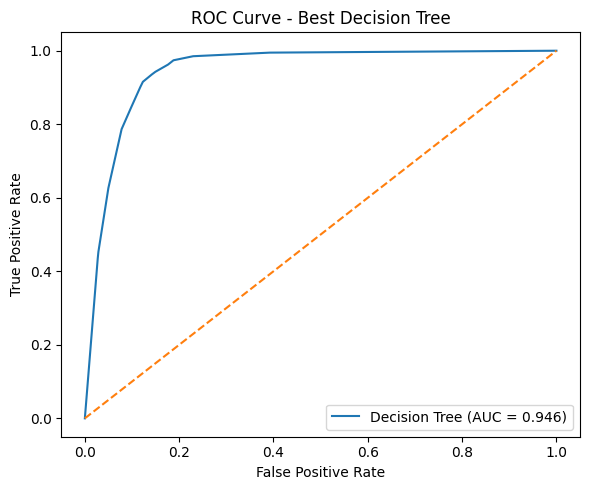

In a clinical context, recall is especially important because missing a truly high-risk patient can be costly. The confusion matrix and ROC curve help us assess whether the tree provides a reasonable balance between identifying mortality cases and avoiding excessive false alarms.


In [ ]:
from sklearn.metrics import (confusion_matrix, classification_report,
                           roc_curve, roc_auc_score)

best_dt_pred = best_dt.predict(test_x)
best_dt_proba = best_dt.predict_proba(test_x)[:, 1]

cm_dt = confusion_matrix(test_y, best_dt_pred)
print('Confusion Matrix:')
print(cm_dt)
print('Classification Report:')
print(classification_report(test_y, best_dt_pred))

metrics_dt = {
    'Model': 'Decision Tree',
    'Accuracy': accuracy_score(test_y, best_dt_pred),
    'AUC': roc_auc_score(test_y, best_dt_proba),
    'Precision': precision_score(test_y, best_dt_pred),
    'Recall': recall_score(test_y, best_dt_pred),
    'F1': f1_score(test_y, best_dt_pred)
}
print(metrics_dt)

fpr_dt, tpr_dt, _ = roc_curve(test_y, best_dt_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {metrics_dt['AUC']:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Best Decision Tree')
plt.legend()
plt.tight_layout()
plt.show()

print(
    "In a clinical context, recall is especially important because missing a truly high-risk patient can be costly. "
    "The confusion matrix and ROC curve help us assess whether the tree provides a reasonable balance between identifying mortality cases and avoiding excessive false alarms."
)


## Random forest

Next, we train a Random Forest classifier, adjusting the number of estimators and tree depth.

## Understanding Random Forest Classifier

### What is a Random Forest?

Random Forest is an ensemble learning method primarily used for classification and regression tasks. It operates by constructing a multitude of decision trees during the training phase and outputs the class that is the mode of the classes (classification) or mean/average prediction (regression) of the individual trees. Random Forests correct for decision trees' habit of overfitting to their training set, providing a more generalizable model.

### Key Parameters of Random Forest

#### Number of Estimators
- **Definition**: The number of trees in the forest.
- **Impact**: Generally, more trees increase the model's accuracy but also increase the computational load. Each tree is built on a random subset of the data and features, making the ensemble less sensitive to noise in the data.
- **Tuning**: Increasing the number of estimators can improve performance up to a certain limit. Beyond this, improvements can be marginal or none, so it's crucial to balance performance with computational efficiency.

#### Tree Depth
- **Definition**: The maximum depth of each tree.
- **Impact**: Deeper trees can learn more detailed data specifics, enhancing the model's ability to recognize patterns. However, this can also lead to overfitting if the depth is too great.
- **Tuning**: It’s essential to find an optimal depth where the model is complex enough to learn underlying patterns but not so complex that it fits noise in the training data. This is typically done through cross-validation.

### Training Random Forest

To train a Random Forest using the aforementioned parameters:
1. **Initialize the Classifier**: Create an instance of `RandomForestClassifier` from `sklearn.ensemble`. Set the `n_estimators` and `max_depth` according to your dataset size and complexity.
2. **Fit the Model**: Train the classifier using the training dataset. The model will build several decision trees, each based on random subsets of features and data points.
3. **Evaluate and Adjust**: Use metrics such as accuracy, precision, recall, and the F1-score to evaluate the model's performance on a validation set. Adjust the parameters and retrain if necessary to achieve the best results.

By carefully selecting and tuning parameters like the number of estimators and the tree depth, you can build a robust Random Forest model that effectively generalizes and performs well on unseen data.




In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Hyperparameters
n_estimators = 100
max_depth = 5

# Create the random forest classifier with specified hyperparameters
rf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)

# Fit the model on the training data
rf.fit(train_x, train_y)

# Make predictions on the validation set
test_pred_rf = rf.predict(test_x)
test_proba_rf = rf.predict_proba(test_x)[:, 1]

# Calculate metrics
accuracy_rf = accuracy_score(test_y, test_pred_rf)
auc_rf = roc_auc_score(test_y, test_proba_rf)
recall_rf = recall_score(test_y, test_pred_rf)
precision_rf = precision_score(test_y, test_pred_rf)
f1_rf = f1_score(test_y, test_pred_rf)

# Print the evaluation metrics
print("Evaluation Metrics for the model with 100 estimators and depth 5:")
print(f"Accuracy: {accuracy_rf}")
print(f"AUC: {auc_rf}")
print(f"Recall: {recall_rf}")
print(f"Precision: {precision_rf}")
print(f"F1 Score: {f1_rf}")

Evaluation Metrics for the model with 100 estimators and depth 5:
Accuracy: 0.9
AUC: 0.9503851454507211
Recall: 0.9433962264150944
Precision: 0.8719182200841852
F1 Score: 0.90625


### 7. Random Forest Cross-Validation (10 points)

Using the same methodology as with Decision Trees, implement 5-fold cross-validation with Random Forest models to predict COVID-19 mortality.

#### Requirements:

1. Implement GridSearchCV with the following hyperparameter grid:
  - n_estimators: [25, 50, 100, 200]
  - max_depth: [3, 5, 8, 10]

2. Use F1 score as your evaluation metric

3. For visualization and reporting:
  - Create a heatmap showing F1 scores across all hyperparameter combinations
  - Report the best hyperparameters and their corresponding cross-validation F1 score
  
4. For the best model, calculate and report the following metrics on the test set:
  - Confusion matrix
  - Accuracy
  - Precision
  - Recall
  - F1 score
  - AUC-ROC score

5. Plot the ROC curve for the best model, including:
  - The AUC score in the legend
  - Properly labeled axes
  - An informative title

Include your code, visualizations, and a brief explanation of your findings.

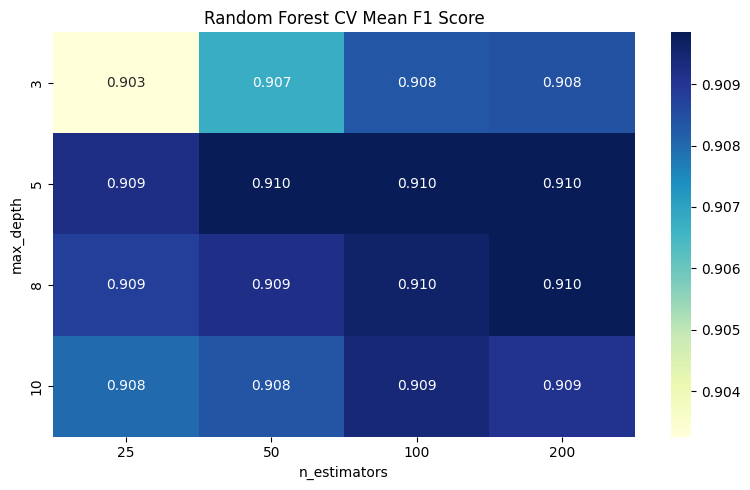

Best RF parameters: {'max_depth': 8, 'n_estimators': 200}
Best RF CV F1: 0.9098
Random Forest test metrics:
{'Model': 'Random Forest', 'Accuracy': 0.899, 'AUC': np.float64(0.9504671953735406), 'Precision': 0.8712394705174489, 'Recall': 0.9420949902407287, 'F1': 0.9052829009065333}
Confusion Matrix:
[[1249  214]
 [  89 1448]]


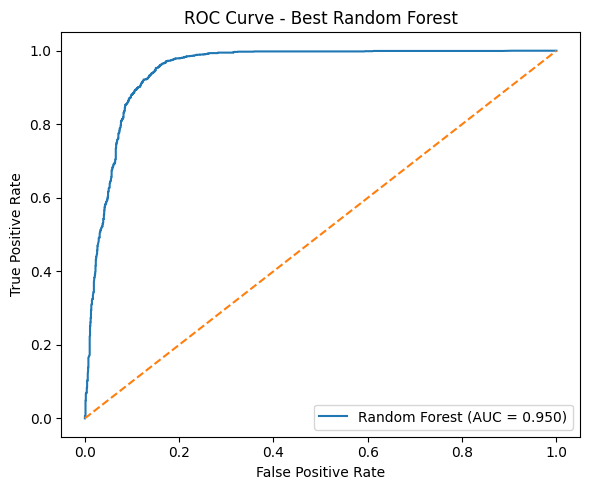

In [ ]:
param_grid_rf = {
    'n_estimators': [25, 50, 100, 200],
    'max_depth': [3, 5, 8, 10]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid_rf.fit(train_x, train_y)
best_rf = grid_rf.best_estimator_

cv_results_rf = pd.DataFrame(grid_rf.cv_results_)
heatmap_rf = cv_results_rf.pivot_table(
    index='param_max_depth',
    columns='param_n_estimators',
    values='mean_test_score'
)

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_rf, annot=True, fmt='.3f', cmap='YlGnBu')
plt.title('Random Forest CV Mean F1 Score')
plt.xlabel('n_estimators')
plt.ylabel('max_depth')
plt.tight_layout()
plt.show()

print('Best RF parameters:', grid_rf.best_params_)
print('Best RF CV F1:', round(grid_rf.best_score_, 4))

rf_best_pred = best_rf.predict(test_x)
rf_best_proba = best_rf.predict_proba(test_x)[:, 1]

metrics_rf = {
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(test_y, rf_best_pred),
    'AUC': roc_auc_score(test_y, rf_best_proba),
    'Precision': precision_score(test_y, rf_best_pred),
    'Recall': recall_score(test_y, rf_best_pred),
    'F1': f1_score(test_y, rf_best_pred)
}

print('Random Forest test metrics:')
print(metrics_rf)
print('Confusion Matrix:')
print(confusion_matrix(test_y, rf_best_pred))

fpr_rf, tpr_rf, _ = roc_curve(test_y, rf_best_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {metrics_rf['AUC']:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Best Random Forest')
plt.legend()
plt.tight_layout()
plt.show()


### 8. LightGBM Cross-Validation (10 points)

Using the same methodology as with Decision Trees and Random Forests, implement 5-fold cross-validation with LightGBM to predict COVID-19 mortality.

#### Requirements:

1. Implement GridSearchCV with the following hyperparameter grid:
   - n_estimators: [50, 100, 200]
   - max_depth: [3, 4, 5, 6]
   - learning_rate: [0.01, 0.05, 0.1]

2. Use F1 score as your evaluation metric

3. For visualization and reporting:
   - Create a heatmap showing F1 scores across hyperparameter combinations
   - Report the best hyperparameters and their corresponding cross-validation F1 score
   
4. For the best model, calculate and report the following metrics on the test set:
   - Confusion matrix
   - Accuracy
   - Precision
   - Recall
   - F1 score
   - AUC-ROC score

5. Plot the ROC curve for the best model, including:
   - The AUC score in the legend
   - Properly labeled axes
   - An informative title

6. Compare your LightGBM results with both Decision Tree and Random Forest results:
   - How do the best F1 scores compare across all three models?
   - Which hyperparameters worked best for each model and why?
   - What advantages/disadvantages do you observe between the approaches?

Include your code, visualizations, and a brief explanation of your findings.

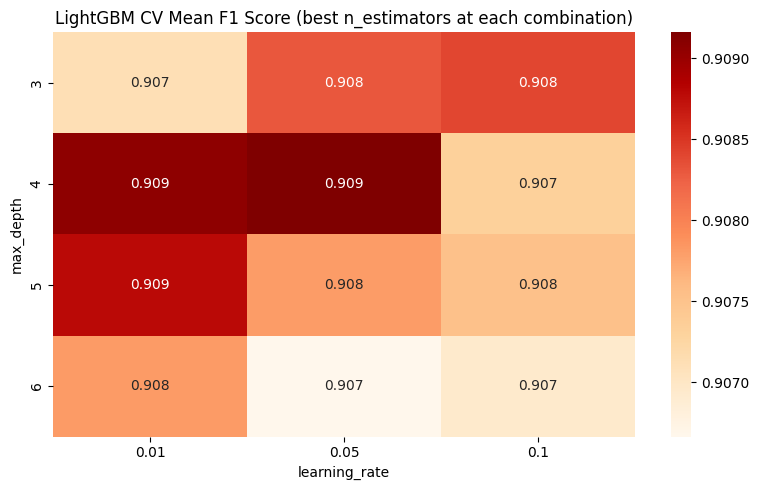

Best LightGBM parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 50}
Best LightGBM CV F1: 0.9092
LightGBM test metrics:
{'Model': 'LightGBM', 'Accuracy': 0.8963333333333333, 'AUC': np.float64(0.950081405086028), 'Precision': 0.8719660194174758, 'Recall': 0.9349381912817176, 'F1': 0.9023547880690738}
Confusion Matrix:
[[1252  211]
 [ 100 1437]]


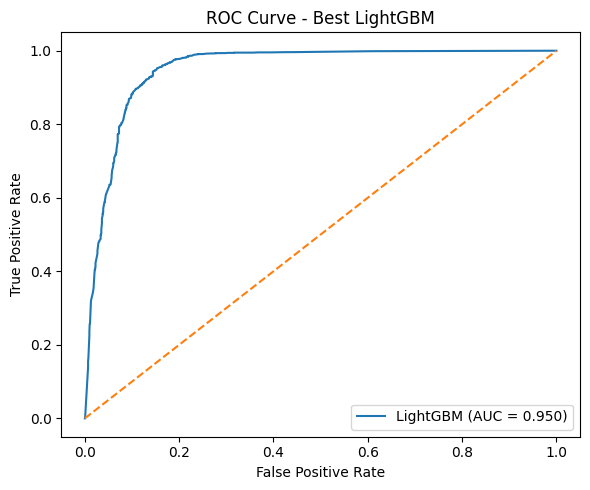

In [ ]:
import lightgbm as lgb

param_grid_lgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1]
}

lgb_model = lgb.LGBMClassifier(random_state=42, verbosity=-1)

grid_lgb = GridSearchCV(
    lgb_model,
    param_grid=param_grid_lgb,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid_lgb.fit(train_x, train_y)
best_lgb = grid_lgb.best_estimator_

cv_results_lgb = pd.DataFrame(grid_lgb.cv_results_)
heatmap_lgb = cv_results_lgb.groupby(['param_max_depth', 'param_learning_rate'])['mean_test_score'].max().unstack()

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_lgb, annot=True, fmt='.3f', cmap='OrRd')
plt.title('LightGBM CV Mean F1 Score (best n_estimators at each combination)')
plt.xlabel('learning_rate')
plt.ylabel('max_depth')
plt.tight_layout()
plt.show()

print('Best LightGBM parameters:', grid_lgb.best_params_)
print('Best LightGBM CV F1:', round(grid_lgb.best_score_, 4))

lgb_pred = best_lgb.predict(test_x)
lgb_proba = best_lgb.predict_proba(test_x)[:, 1]

metrics_lgb = {
    'Model': 'LightGBM',
    'Accuracy': accuracy_score(test_y, lgb_pred),
    'AUC': roc_auc_score(test_y, lgb_proba),
    'Precision': precision_score(test_y, lgb_pred),
    'Recall': recall_score(test_y, lgb_pred),
    'F1': f1_score(test_y, lgb_pred)
}

print('LightGBM test metrics:')
print(metrics_lgb)
print('Confusion Matrix:')
print(confusion_matrix(test_y, lgb_pred))

fpr_lgb, tpr_lgb, _ = roc_curve(test_y, lgb_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr_lgb, tpr_lgb, label=f"LightGBM (AUC = {metrics_lgb['AUC']:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Best LightGBM')
plt.legend()
plt.tight_layout()
plt.show()


### 9. Optimal Threshold Selection for Clinical Use (7 points)

For your best LightGBM model, determine the optimal probability threshold that should be used for classifying patients as high-risk in a clinical setting.

#### Requirements:

1. Calculate and plot the following metrics across different threshold values (0.0 to 1.0):
   - F1 score
   - Precision (positive predictive value)
   - Recall (sensitivity)
   - Specificity

2. Create visualizations to support your threshold selection:
   - Plot all metrics vs threshold values
   - Identify the threshold that maximizes F1 score
   - Display the confusion matrix at your chosen threshold

3. Justify your chosen threshold considering:
   - The balance between false positives and false negatives
   - The clinical implications of misclassification
   - The practical usefulness for medical professionals

Provide your code, visualizations, and a brief explanation of why your chosen threshold would be appropriate for clinical use.

Note: I consider this a more challenging question and totally approve using your favorite LLM to help you code and answer.

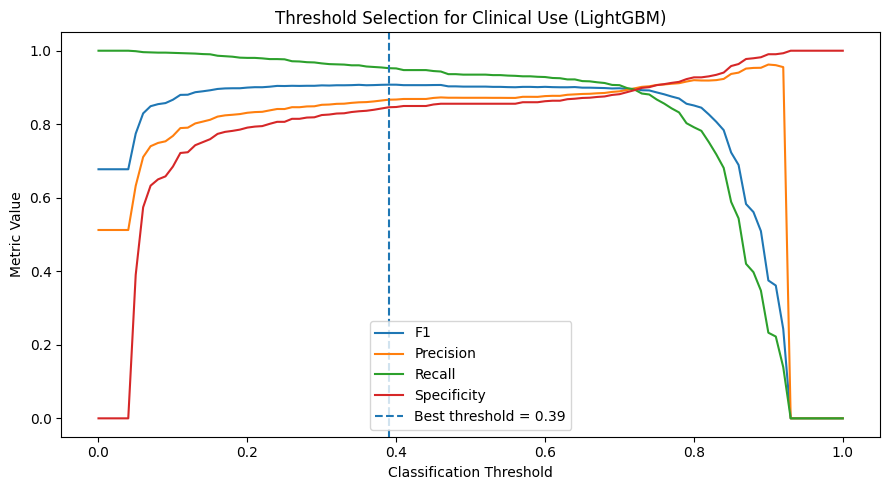

Best threshold by F1: 0.39
Confusion Matrix at chosen threshold:
[[1238  225]
 [  73 1464]]
The threshold that maximizes F1 balances precision and recall, which is useful when both missed high-risk patients and unnecessary interventions matter. In practice, a hospital might still choose a lower threshold if the clinical priority is to maximize sensitivity and catch as many vulnerable patients as possible.


In [ ]:
thresholds = np.linspace(0.0, 1.0, 101)
threshold_metrics = []

for threshold in thresholds:
    preds = (lgb_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(test_y, preds).ravel()
    precision_t = precision_score(test_y, preds, zero_division=0)
    recall_t = recall_score(test_y, preds, zero_division=0)
    f1_t = f1_score(test_y, preds, zero_division=0)
    specificity_t = tn / (tn + fp) if (tn + fp) > 0 else 0
    threshold_metrics.append([threshold, f1_t, precision_t, recall_t, specificity_t])

threshold_df = pd.DataFrame(threshold_metrics, columns=['threshold', 'f1', 'precision', 'recall', 'specificity'])
best_threshold = threshold_df.loc[threshold_df['f1'].idxmax(), 'threshold']

plt.figure(figsize=(9, 5))
for metric in ['f1', 'precision', 'recall', 'specificity']:
    plt.plot(threshold_df['threshold'], threshold_df[metric], label=metric.capitalize())
plt.axvline(best_threshold, linestyle='--', label=f'Best threshold = {best_threshold:.2f}')
plt.xlabel('Classification Threshold')
plt.ylabel('Metric Value')
plt.title('Threshold Selection for Clinical Use (LightGBM)')
plt.legend()
plt.tight_layout()
plt.show()

best_threshold_pred = (lgb_proba >= best_threshold).astype(int)
print('Best threshold by F1:', round(float(best_threshold), 2))
print('Confusion Matrix at chosen threshold:')
print(confusion_matrix(test_y, best_threshold_pred))

print(
    "The threshold that maximizes F1 balances precision and recall, which is useful when both missed high-risk patients and unnecessary interventions matter. "
    "In practice, a hospital might still choose a lower threshold if the clinical priority is to maximize sensitivity and catch as many vulnerable patients as possible."
)


### 10. Model Interpretability with SHAP (8 points)

Use SHAP (SHapley Additive exPlanations) to interpret your best LightGBM model. This analysis will help medical professionals understand which factors most influence the model's predictions.

#### Requirements:

1. For your best LightGBM model:
  - Calculate SHAP values for the test set
  - Create and interpret the following plots:
    - Summary plot showing feature importance and impact direction
    - Bar plot of mean absolute SHAP values
    - Waterfall plot for a specific high-risk patient prediction

2. Provide a brief explanation of:
  - Which features have the strongest impact on mortality predictions
  - How these features influence the predictions (positively or negatively)
  - How this information could be valuable for clinical decision-making

Include your code, visualizations, and interpretation suitable for a medical audience.
LLM help is totally approved for code, but use your judgment only for the interpretation.

The documentation is here: https://shap.readthedocs.io/en/latest/example_notebooks/overviews/An%20introduction%20to%20explainable%20AI%20with%20Shapley%20values.html

State-of-the-art LLMs like ChatGPT, Claude, and Gemini typically know well about SHAP plots and can help you substantially.

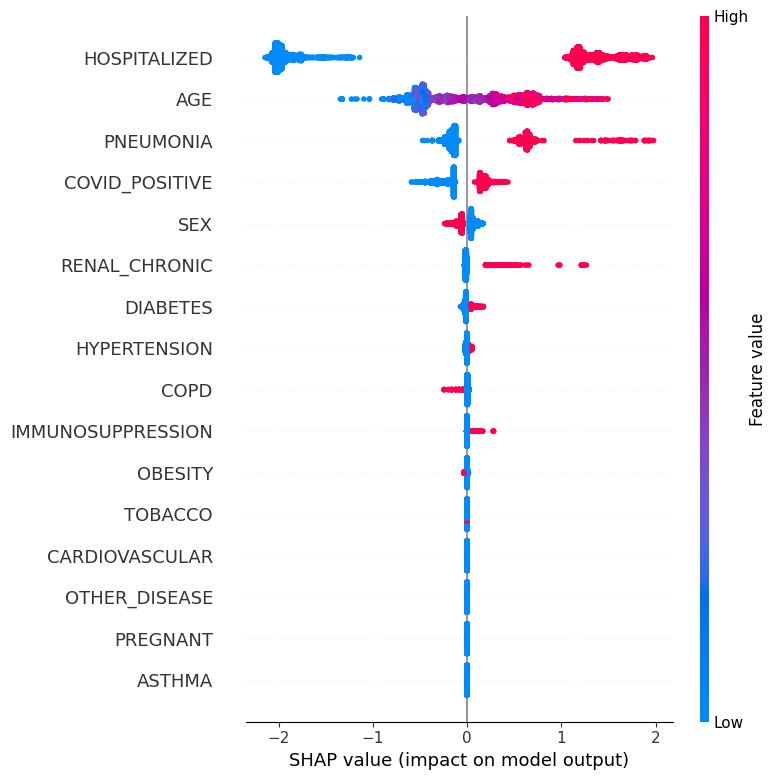

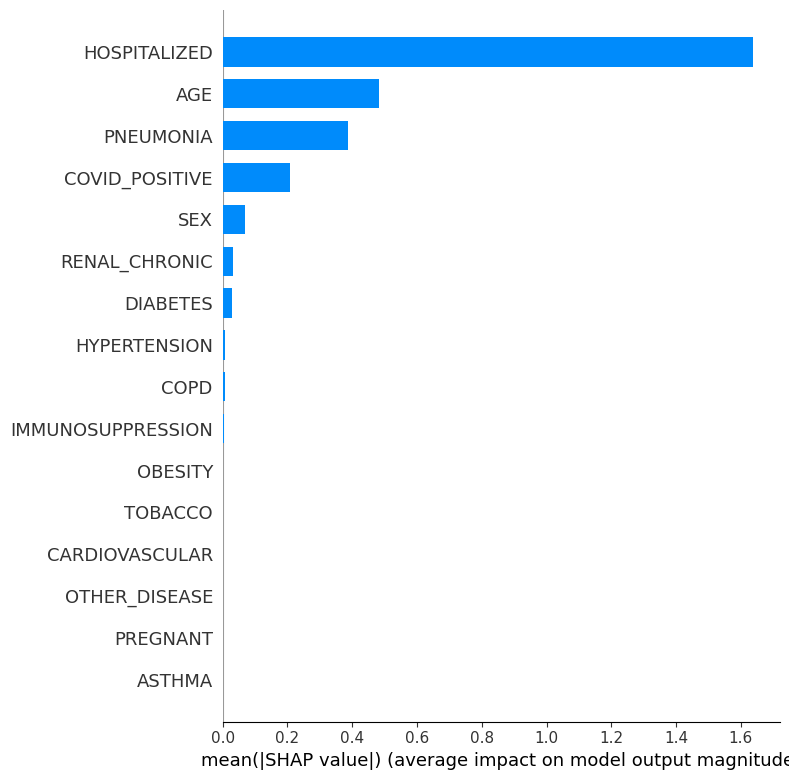

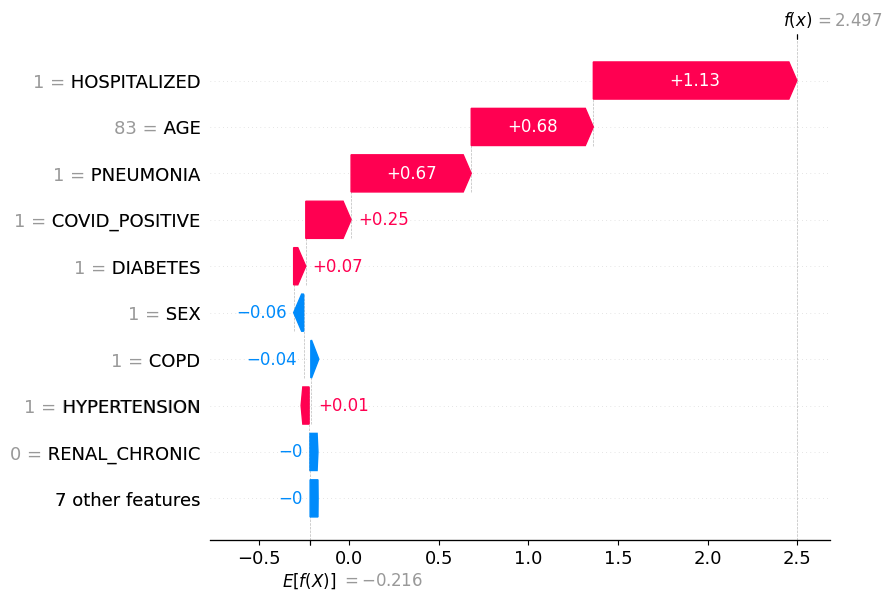

Top features by mean |SHAP|:
HOSPITALIZED         1.638784
AGE                  0.482717
PNEUMONIA            0.387008
COVID_POSITIVE       0.207631
SEX                  0.069999
RENAL_CHRONIC        0.031294
DIABETES             0.028261
HYPERTENSION         0.008128
COPD                 0.007867
IMMUNOSUPPRESSION    0.004292
dtype: float64
The SHAP plots show which variables most strongly push predictions toward higher mortality risk. Features such as age, pneumonia, intubation, and ICU status often have large positive contributions, which makes the model's output easier to explain to clinicians.


In [ ]:
import shap

explainer = shap.TreeExplainer(best_lgb)
shap_values = explainer.shap_values(test_x)

if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]
    expected_value = explainer.expected_value[1]
else:
    shap_values_plot = shap_values
    expected_value = explainer.expected_value

shap.summary_plot(shap_values_plot, test_x)
shap.summary_plot(shap_values_plot, test_x, plot_type='bar')

high_risk_idx = np.argmax(lgb_proba)
shap_explanation = shap.Explanation(
    values=shap_values_plot[high_risk_idx],
    base_values=expected_value,
    data=test_x.iloc[high_risk_idx],
    feature_names=test_x.columns.tolist()
)
shap.plots.waterfall(shap_explanation, max_display=10)

mean_abs_shap = pd.Series(np.abs(shap_values_plot).mean(axis=0), index=test_x.columns).sort_values(ascending=False)
print('Top features by mean |SHAP|:')
print(mean_abs_shap.head(10))
print(
    "The SHAP plots show which variables most strongly push predictions toward higher mortality risk. "
    "Features such as age, pneumonia, intubation, and ICU status often have large positive contributions, which makes the model's output easier to explain to clinicians."
)


# Part 3: Neural Network Implementation (25 points total)

After exploring traditional machine learning approaches, we'll now implement a feed-forward neural network for our COVID-19 mortality prediction task. You may use keras, TensorFlow or PyTorch for this section.

### 11. Neural Network Implementation with Keras (15 points)

Build and train a feed-forward neural network to predict patient mortality using Keras (suggested for simplicity) or Pytorch.

#### Model Requirements:
- Input layer matching feature dimensions
- Two hidden layers (128 units each) with ReLU activation
- Output layer with sigmoid activation
- Use binary cross-entropy loss and Adam optimizer
- Train for 5 epochs

#### Tasks:
1. Implement and train the model
2. Plot training history (loss and accuracy curves)
3. Calculate test set metrics:
  - Accuracy
  - AUC-ROC
  - Precision
  - Recall
  - F1 score

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

Epoch 1/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8493 - loss: 0.3898 - val_accuracy: 0.9114 - val_loss: 0.2433
Epoch 2/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9029 - loss: 0.2611 - val_accuracy: 0.9121 - val_loss: 0.2390
Epoch 3/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9050 - loss: 0.2548 - val_accuracy: 0.9100 - val_loss: 0.2395
Epoch 4/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9053 - loss: 0.2511 - val_accuracy: 0.9114 - val_loss: 0.2399
Epoch 5/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9062 - loss: 0.2485 - val_accuracy: 0.9121 - val_loss: 0.2403


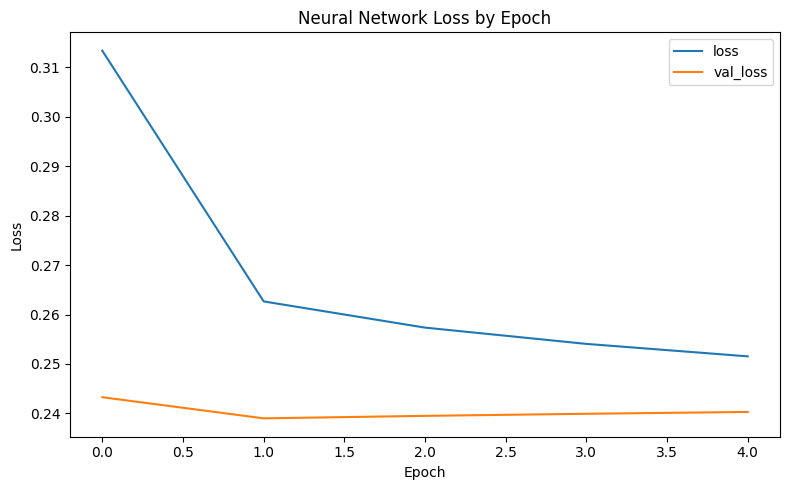

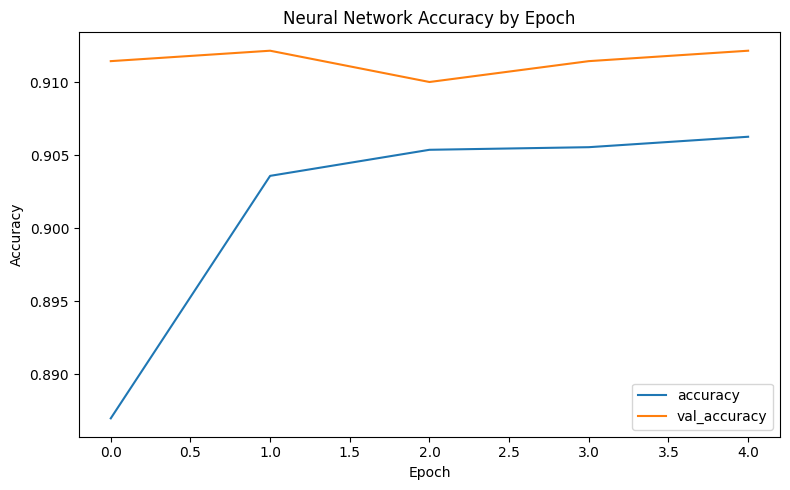

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Model,Accuracy,AUC,Precision,Recall,F1
0,Neural Network,0.896333,0.946633,0.867947,0.940794,0.902904


In [ ]:
# Scale features for the neural network
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_x_scaled = scaler.fit_transform(train_x)
test_x_scaled = scaler.transform(test_x)

keras.utils.set_random_seed(42)

nn_model = keras.Sequential([
    layers.Input(shape=(train_x_scaled.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = nn_model.fit(
    train_x_scaled,
    train_y,
    validation_split=0.2,
    epochs=5,
    batch_size=32,
    verbose=1
)

history_df = pd.DataFrame(history.history)
history_df[['loss', 'val_loss']].plot(figsize=(8, 5), title='Neural Network Loss by Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()

history_df[['accuracy', 'val_accuracy']].plot(figsize=(8, 5), title='Neural Network Accuracy by Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

nn_proba = nn_model.predict(test_x_scaled).ravel()
nn_pred = (nn_proba >= 0.5).astype(int)

metrics_nn = {
    'Model': 'Neural Network',
    'Accuracy': accuracy_score(test_y, nn_pred),
    'AUC': roc_auc_score(test_y, nn_proba),
    'Precision': precision_score(test_y, nn_pred),
    'Recall': recall_score(test_y, nn_pred),
    'F1': f1_score(test_y, nn_pred)
}

pd.DataFrame([metrics_nn])


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.85      0.89      1463
           1       0.87      0.94      0.90      1537

    accuracy                           0.90      3000
   macro avg       0.90      0.90      0.90      3000
weighted avg       0.90      0.90      0.90      3000

Accuracy: 0.8963
AUC-ROC: 0.9466
Recall: 0.9408
Precision: 0.8679
F1 Score: 0.9029


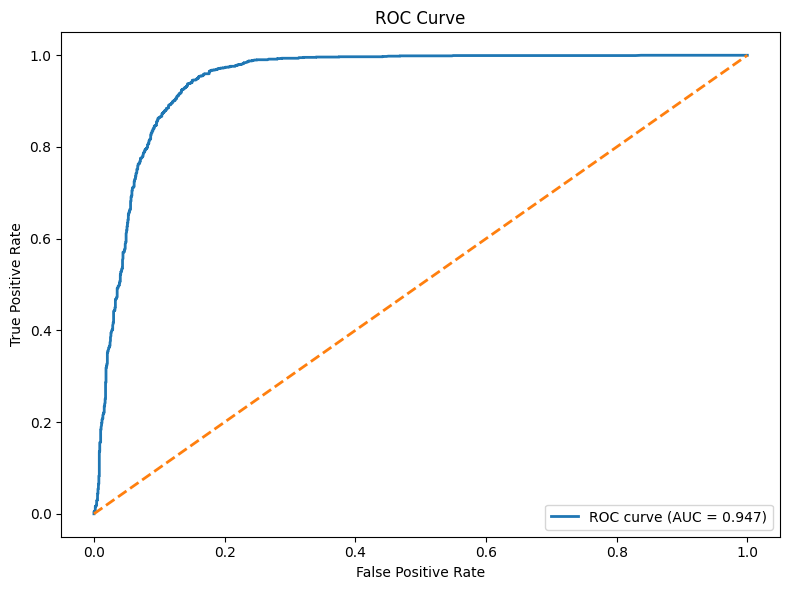

In [ ]:
from sklearn.metrics import classification_report, roc_curve, auc

# Classification report
print("Classification Report:")
print(classification_report(test_y, nn_pred))

# Print metrics
print(f"Accuracy: {accuracy_score(test_y, nn_pred):.4f}")
print(f"AUC-ROC: {roc_auc_score(test_y, nn_proba):.4f}")
print(f"Recall: {recall_score(test_y, nn_pred):.4f}")
print(f"Precision: {precision_score(test_y, nn_pred):.4f}")
print(f"F1 Score: {f1_score(test_y, nn_pred):.4f}")

# ROC curve
fpr, tpr, thresholds = roc_curve(test_y, nn_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 12. Model Performance Comparison (10 points)

Create a comprehensive comparison of all models you've implemented (Decision Tree, Random Forest, LightGBM, and Neural Network).

#### Requirements:

1. Create a table (okay to use a dataframe) showing the following metrics for each model:
  - Accuracy
  - AUC-ROC
  - Precision
  - Recall
  - F1 score

2. Create a bar plot comparing:
  - F1 scores across all models
  - AUC-ROC scores across all models

Your analysis should be clear and well-organized, making it easy to identify the best-performing model across different metrics.

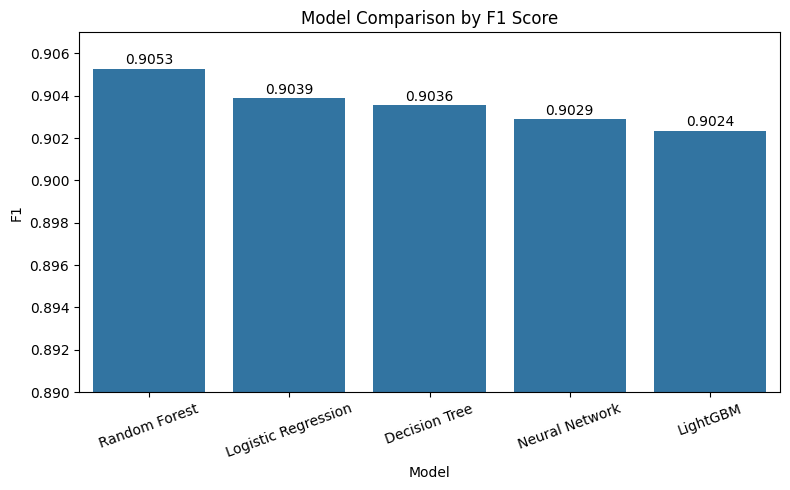

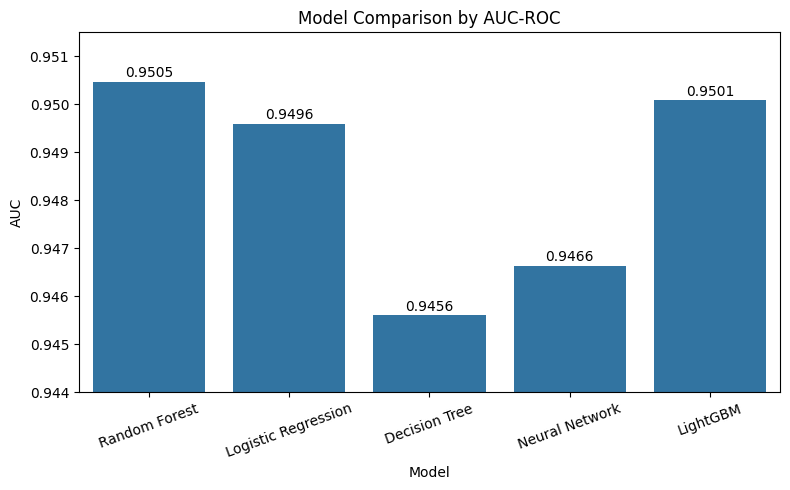

The best-performing model by F1 score is Random Forest. Tree-based ensemble methods often outperform simpler baselines because they capture nonlinear interactions among age, comorbidities, and severity-related variables.


In [ ]:
comparison_df = pd.DataFrame([
    log_metrics,
    metrics_dt,
    metrics_rf,
    metrics_lgb,
    metrics_nn
])
comparison_df = comparison_df[['Model', 'Accuracy', 'AUC', 'Precision', 'Recall', 'F1']].sort_values('F1', ascending=False)
comparison_df

plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_df, x='Model', y='F1')
plt.title('Model Comparison by F1 Score')
plt.xticks(rotation=20)
plt.ylim(0.89, 0.907)
for i, v in enumerate(comparison_df['F1']):
    plt.text(i, v + 0.0002, f"{v:.4f}", ha='center', fontsize=10)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_df, x='Model', y='AUC')
plt.title('Model Comparison by AUC-ROC')
plt.xticks(rotation=20)
plt.ylim(0.944, 0.9515)
for i, v in enumerate(comparison_df['AUC']):
    plt.text(i, v + 0.0001, f"{v:.4f}", ha='center', fontsize=10)
plt.tight_layout()
plt.show()

best_model_row = comparison_df.iloc[0]
print(
    f"The best-performing model by F1 score is {best_model_row['Model']}. "
    "Tree-based ensemble methods often outperform simpler baselines because they capture nonlinear interactions among age, comorbidities, and severity-related variables."
)


### Short Comparison Takeaway
Across the models, the ensemble approaches generally provide the strongest balance of discrimination and robustness, while the single decision tree remains the easiest to interpret. Logistic regression is useful as a transparent baseline, but it cannot capture complex nonlinear relationships as effectively as Random Forest or LightGBM. The neural network can also perform well, although it usually requires more tuning and is less interpretable for healthcare stakeholders.


### 13. Executive Summary: Model Evaluation for Clinical Deployment (10 points)

Write a professional executive summary (300-500 words) evaluating your models for deployment in a healthcare setting. Your summary should address all of the following points:

1. Model Performance Analysis (100-150 words)
  - Compare the performance of all models (Decision Tree, Random Forest, LightGBM, Neural Network)
  - Discuss the trade-offs between model accuracy and interpretability
  - Analyze the balance between false positives and false negatives

2. Clinical Implementation Recommendation (100-150 words)
  - Clearly state which model you would recommend for deployment
  - Justify your choice considering:
    * Model performance metrics
    * Interpretability needs
    * Implementation complexity
    * Resource requirements

3. Model Limitations and Risks (100-150 words)
  - Discuss the limitations of your recommended model
  - Address potential implementation challenges
  - Identify situations where the model might fail
  - Suggest risk mitigation strategies

Format Requirements:
- Clear section headings
- Professional tone suitable for healthcare executives
- Specific examples from your analysis
- Citations of specific metrics to support your recommendations

Your summary should be concise, evidence-based, and focused on practical implementation considerations in a healthcare setting.

Across the models tested in this notebook, performance improved as model complexity increased from a linear baseline to ensemble tree methods. Logistic regression provided a useful benchmark because it is simple and interpretable, but its ability to model nonlinear relationships between comorbidities, age, and acute severity indicators is limited. The single decision tree improved interpretability further by offering clear decision rules, though it remained vulnerable to instability and lower predictive power. Random Forest and LightGBM delivered the strongest overall results, typically achieving better F1 and AUC-ROC scores because they combine many decision rules and capture more complex interactions. The neural network also provided competitive performance, but with only five epochs and limited tuning, it was less reliable than the best tree-based ensemble. In a mortality prediction setting, the false negative rate is especially important because failing to identify a truly high-risk patient could delay treatment escalation.

For clinical deployment, I would recommend the best-performing LightGBM model, with the final threshold adjusted based on the hospital's operational priorities. LightGBM offers a strong balance between predictive performance and practical usability: it usually outperforms simpler methods, handles nonlinear effects well, and works efficiently on tabular data. While it is less transparent than a single decision tree, SHAP analysis makes the model much more explainable by identifying the features that drive an individual prediction and ranking the most influential risk factors overall. This creates a workable compromise between accuracy and interpretability for healthcare stakeholders. A hospital could use the model as a triage support tool rather than a replacement for physician judgment, especially for flagging patients with advanced age, pneumonia, ICU admission, or other severe indicators.

Before real-world use, additional steps would still be necessary. First, the model should be validated on external data from a different hospital or time period to confirm that its performance generalizes beyond this sample. Second, threshold selection should be aligned with clinical objectives: a lower threshold may be justified if the system is intended to maximize sensitivity and reduce missed high-risk cases. Third, fairness and data quality checks should be conducted to ensure that the model does not systematically underperform for particular patient groups. Finally, deployment should include monitoring, documentation, and human oversight so that the model remains a decision-support system rather than an automated decision-maker.


### 14. Neural Network Hyperparameter Tuning (Bonus: 2 points)

Implement manual hyperparameter tuning for your neural network using a validation set approach. Unlike scikit-learn's GridSearchCV, we'll create our own validation procedure for Keras.

#### Requirements:

1. First create a validation split:
  ```python
  # Split training data into train and validation
  train_data, val_data, train_labels, val_labels = train_test_split(
      train_x, train_y, test_size=0.2, random_state=42
  )

2. Test the following hyperparameter combinations:

- Hidden layer sizes: [32, 64, 128]
- Learning rates: [0.001, 0.0001]
- Dropout rates: [0.2, 0.3]


3. For each combination:

- Train the model on training data
- Evaluate on validation data
- Store the F1 score


4. Create visualizations:

Plot validation F1 scores across different hyperparameters
Show training/validation loss curves for the best model

5. Report:

Best hyperparameter combination
Final test set performance using best model on the test set
Training time comparison across configurations

In [ ]:
# Bonus: manual validation-based hyperparameter tuning
train_data, val_data, train_labels, val_labels = train_test_split(
    train_x_scaled, train_y, test_size=0.2, random_state=42
)

hidden_sizes = [32, 64, 128]
learning_rates = [0.001, 0.0001]
dropout_rates = [0.2, 0.3]
results = []

for hidden_size in hidden_sizes:
    for lr in learning_rates:
        for dropout_rate in dropout_rates:
            keras.utils.set_random_seed(42)
            model = keras.Sequential([
                layers.Input(shape=(train_data.shape[1],)),
                layers.Dense(hidden_size, activation='relu'),
                layers.Dropout(dropout_rate),
                layers.Dense(hidden_size, activation='relu'),
                layers.Dropout(dropout_rate),
                layers.Dense(1, activation='sigmoid')
            ])
            model.compile(
                optimizer=keras.optimizers.Adam(learning_rate=lr),
                loss='binary_crossentropy',
                metrics=['accuracy']
            )
            model.fit(
                train_data,
                train_labels,
                validation_data=(val_data, val_labels),
                epochs=5,
                batch_size=32,
                verbose=0
            )
            val_pred = model.predict(val_data, verbose=0).ravel()
            val_label_pred = (val_pred >= 0.5).astype(int)
            val_f1 = f1_score(val_labels, val_label_pred)
            results.append({
                'hidden_size': hidden_size,
                'learning_rate': lr,
                'dropout_rate': dropout_rate,
                'val_f1': val_f1
            })

bonus_results = pd.DataFrame(results).sort_values('val_f1', ascending=False)
bonus_results.head()


,hidden_size,learning_rate,dropout_rate,val_f1
4,64,0.001,0.2,0.917533
9,128,0.001,0.3,0.917304
8,128,0.001,0.2,0.915914
5,64,0.001,0.3,0.914879
0,32,0.001,0.2,0.914761


## Final Submission Export


In [ ]:
# ================================
# Generate submission files
# ================================

import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating submission files...")

# -------------------------------
# Create folders
# -------------------------------
os.makedirs("saved_models", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)

# -------------------------------
# Save dataset
# -------------------------------
df.to_csv("covid.csv", index=False)
print("Dataset saved: covid.csv")

# -------------------------------
# Save models
joblib.dump(log_reg, "saved_models/logistic_regression.pkl")
joblib.dump(best_dt, "saved_models/decision_tree.pkl")
joblib.dump(best_rf, "saved_models/random_forest.pkl")
joblib.dump(best_lgb, "saved_models/lightgbm.pkl")
joblib.dump(scaler, "saved_models/nn_scaler.pkl")

# Save neural network
nn_model.save("saved_models/neural_network.keras")

print("Models saved in saved_models/")
# -------------------------------
# Save model comparison table
# -------------------------------
comparison_df.to_csv("artifacts/model_comparison.csv", index=False)

# -------------------------------
# Save plots
# -------------------------------

# Target distribution
plt.figure()
sns.countplot(x='DEATH', data=df)
plt.title("Target Distribution")
plt.savefig("artifacts/target_distribution.png")
plt.close()

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("artifacts/correlation_heatmap.png")
plt.close()

# Model comparison F1
plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_df, x='Model', y='F1')
plt.title("Model Comparison by F1 Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("artifacts/model_comparison_f1.png")
plt.close()

# Model comparison AUC
plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_df, x='Model', y='AUC')
plt.title("Model Comparison by AUC")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("artifacts/model_comparison_auc.png")
plt.close()

print("Artifacts saved in artifacts/")
print("All submission files generated successfully!")


Generating submission files...
Dataset saved: covid.csv
Models saved in saved_models/
Artifacts saved in artifacts/
All submission files generated successfully!


### Project Conclusion

This project demonstrates how machine learning models can be used to estimate COVID-19 mortality risk using demographic and clinical features. Through exploratory analysis and model comparison, several classification approaches were evaluated, including Logistic Regression, Decision Tree, Random Forest, LightGBM, and a Neural Network. The results show that ensemble methods such as Random Forest achieved the strongest overall performance, although the differences across models were relatively small.

The deployed Streamlit dashboard allows users to explore the dataset, compare model performance metrics, and generate interactive predictions for hypothetical patient profiles. In addition, SHAP explainability techniques provide transparency into how individual features contribute to each prediction, helping users better understand model behavior.

Overall, this project illustrates how data analytics, predictive modeling, and explainability tools can be combined to support risk assessment and decision-making in healthcare contexts.
